В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

In [192]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# **Завдання 1.**
Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [218]:
import pandas as pd
medical_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/medical-charges (2).csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [219]:
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


У даній задачі незалежною змінною є вік (`age`), цільовою змінною є розмір виплати (`charges`)

In [23]:
X_row = np.array(non_smoker_df['age'])
X = np.expand_dims(X_row, axis = 1)
print("Вектор-стовпець незалежних змінних X:\n",X)

y_row = np.array(non_smoker_df['charges'])
y = np.expand_dims(y_row, axis = 1)
print("Вектор-стовпець цільової (залежної) змінної у:\n", y)

Вектор-стовпець незалежних змінних X:
 [[18]
 [28]
 [33]
 ...
 [18]
 [18]
 [21]]
Вектор-стовпець цільової (залежної) змінної у:
 [[ 1725.5523 ]
 [ 4449.462  ]
 [21984.47061]
 ...
 [ 2205.9808 ]
 [ 1629.8335 ]
 [ 2007.945  ]]


##1. Метод МНК

In [25]:
# Додаємо колонку одиниць аби задати bias терм (константу в моделі регресії)
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]
X[:3], X_with_intercept[:3]

(array([[18],
        [28],
        [33]]),
 array([[ 1., 18.],
        [ 1., 28.],
        [ 1., 33.]]))

In [26]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [28]:
#Знайдемо значення коефіцієнтів методом НК
MNK_coefs = normal_equations(X_with_intercept, y)
print(MNK_coefs)

[[-2091.42055657]
 [  267.24891283]]


In [29]:
#Шляхом множення матриці незалежних змінних на коефіцієнти з МНК,
# отримаємо прогнозовані значення цільової змінної для кожної точки незалежної змінної
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)

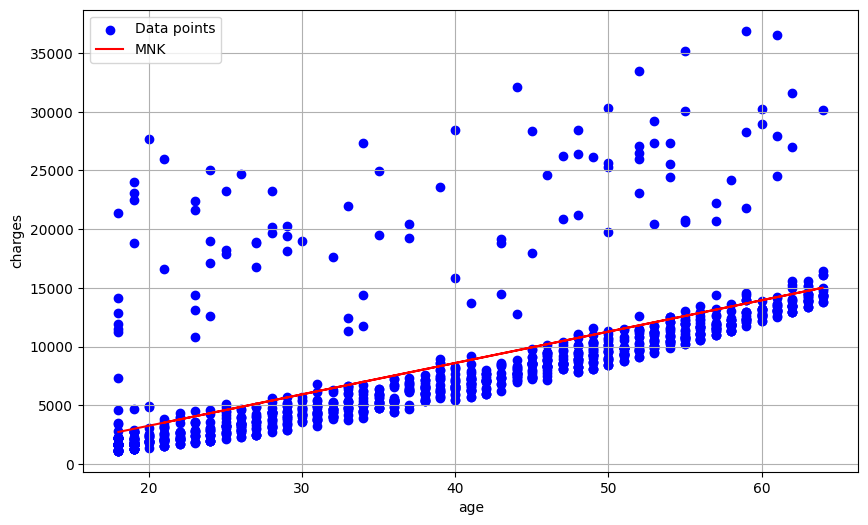

In [237]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, color='blue', label='Data points')
plt.plot(X[:, 0], predictions_MNK, color='red', label='MNK')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
#Порахуємо точність прогнозу за RMSE та оцінимо загалом якість моделі
r2_MNK = r2_score(y, predictions_MNK)
rmse_MNK = root_mean_squared_error(y, predictions_MNK)
mae_MNK = mean_absolute_error(y, predictions_MNK)

print(f"R² score: {r2_MNK:.2f}")
print(f"Root Mean Squared Error: {rmse_MNK:.2f}")
print(f"Mean Absolute Error: {mae_MNK:.2f}")

print(f"STD for y: {np.std(y):.2f}")


R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52
STD for y: 5990.96


In [34]:
np.mean(y), np.std(y), np.min(y)

(np.float64(8434.268297856204),
 np.float64(5990.9645302876115),
 np.float64(1121.8739))

## 2. Full-Batch градієнтного спуску

In [48]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(np.sum(np.square(error)))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

Для методу градієнтоного спуску розмірність `y` потрібно забезпечити `(n,)`, оскільки `y_pred` матиме таку ж розмірність. Співпадіння розмірностей необхідне для обчислення помилок.

In [59]:
y=y.reshape(-1)

Спробуємо різні значення learning rate та кількість епох навчання

In [149]:
m1, b1, errors1 = full_batch_gradient_descent(X, y, lr = 0.001, epochs=100)

In [150]:
print('m1:', m1)
print('b1:', b1)
print('errors1 last value:', errors1[-1])

m1: -1.3967624262082842e+42
b1: -3.1448925830775484e+40
errors1 last value: 5.813721557091237e+89


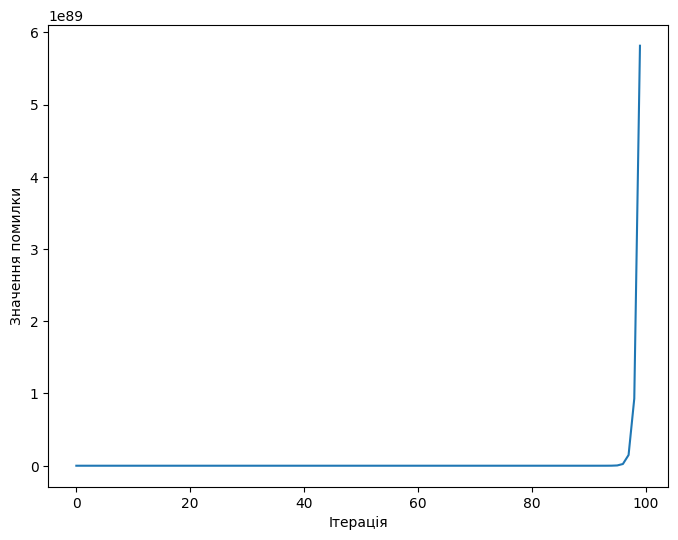

In [154]:
plt.figure(figsize=(8, 6))
plt.plot(errors1)
plt.xlabel('Ітерація')
plt.ylabel('Значення помилки')
plt.show()

Дане значення learning rate очевидно є завеликим, оскільки функція помилок розходиться

In [158]:
m2, b2, errors2 = full_batch_gradient_descent(X, y, lr = 0.0001, epochs=50)

In [159]:
print('m2:', m2)
print('b2:', b2)
print('errors2 last value:', errors2[-1])

m2: 220.10120736081387
b2: 2.5823897309828774
errors2 last value: 23658751959.420776


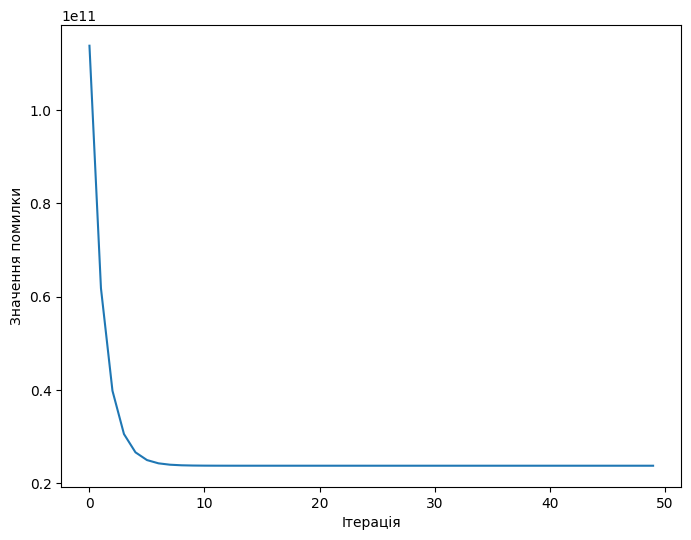

In [160]:
plt.figure(figsize=(8, 6))
plt.plot(errors2)
plt.xlabel('Ітерація')
plt.ylabel('Значення помилки')
plt.show()

In [171]:
m3, b3, errors3 = full_batch_gradient_descent(X, y, lr = 0.00001, epochs=200)

In [172]:
print('m3:', m3)
print('b3:', b3)
print('errors3 last value:', errors3[-1])

m3: 219.89234776351717
b3: 4.001365238258868
errors3 last value: 23659511462.052097


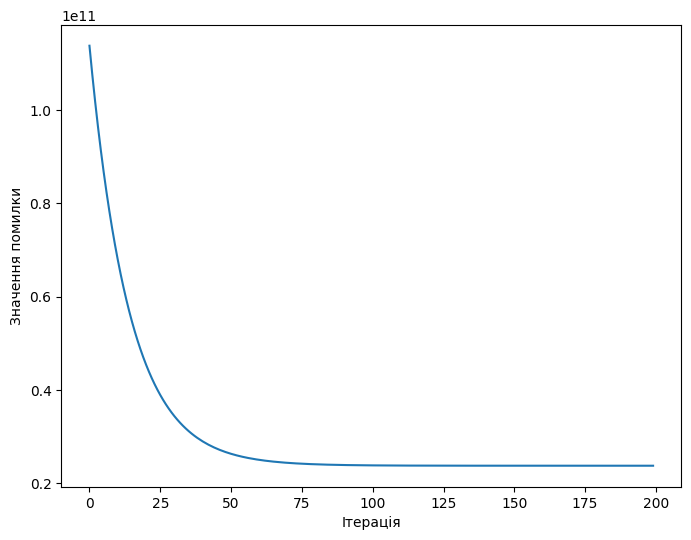

In [173]:
plt.figure(figsize=(8, 6))
plt.plot(errors3)
plt.xlabel('Ітерація')
plt.ylabel('Значення помилки')
plt.show()

In [182]:
m4, b4, errors4 = full_batch_gradient_descent(X, y, lr = 0.000001, epochs=2000)

In [183]:
print('m4:', m4)
print('b4:', b4)
print('errors4 last value:', errors4[-1])

m4: 219.87115681980458
b4: 4.000889079134902
errors4 last value: 23659520316.38514


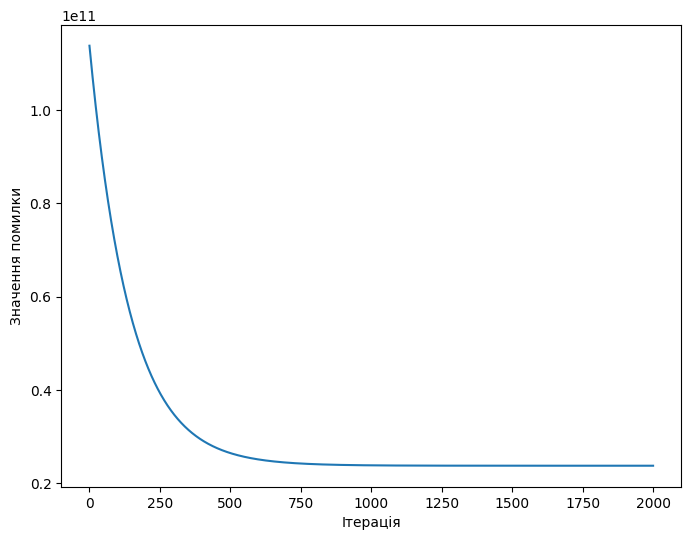

In [184]:
plt.figure(figsize=(8, 6))
plt.plot(errors4)
plt.xlabel('Ітерація')
plt.ylabel('Значення помилки')
plt.show()

Для 3 та 4 варіантів значення коефіцієнтів та останнього значення масиву помилок приблизно однакові. Порівняємо RMSE, R^2, та MAE для цих двох варіантів коефіцієнтів.

In [203]:
predictions3_fbgd = m3 * X[:, 0] + b3

In [204]:
predictions4_fbgd = m4 * X[:, 0] + b4

In [206]:
#Порахуємо точність прогнозу за RMSE та оцінимо загалом якість моделі
r2_fbgd3 = r2_score(y, predictions3_fbgd)
rmse_fbgd3 = root_mean_squared_error(y, predictions3_fbgd)
mae_fbgd3 = mean_absolute_error(y, predictions3_fbgd)

r2_fbgd4 = r2_score(y, predictions4_fbgd)
rmse_fbgd4 = root_mean_squared_error(y, predictions4_fbgd)
mae_fbgd4 = mean_absolute_error(y, predictions4_fbgd)

print('m3, b3')
print(f"R² score: {r2_fbgd3:.2f}")
print(f"Root Mean Squared Error: {rmse_fbgd3:.2f}")
print(f"Mean Absolute Error: {mae_fbgd3:.2f}")

print('\nm4, b4')
print(f"R² score: {r2_fbgd4:.2f}")
print(f"Root Mean Squared Error: {rmse_fbgd4:.2f}")
print(f"Mean Absolute Error: {mae_fbgd4:.2f}")

m3, b3
R² score: 0.38
Root Mean Squared Error: 4715.55
Mean Absolute Error: 2805.90

m4, b4
R² score: 0.38
Root Mean Squared Error: 4715.55
Mean Absolute Error: 2805.42


На основі отриманих результатів видно, що обидва набори коефіцієнтів мають загалом однакові показники якості.
Таким чином, можна зробити висновок, що ефективнішим (дешевшим та швидшим без втрати якості) є варіант із значеннями:
`learning_rate` = 0.00001
`epochs` = 200

In [207]:
predictions_fbgd = predictions3_fbgd

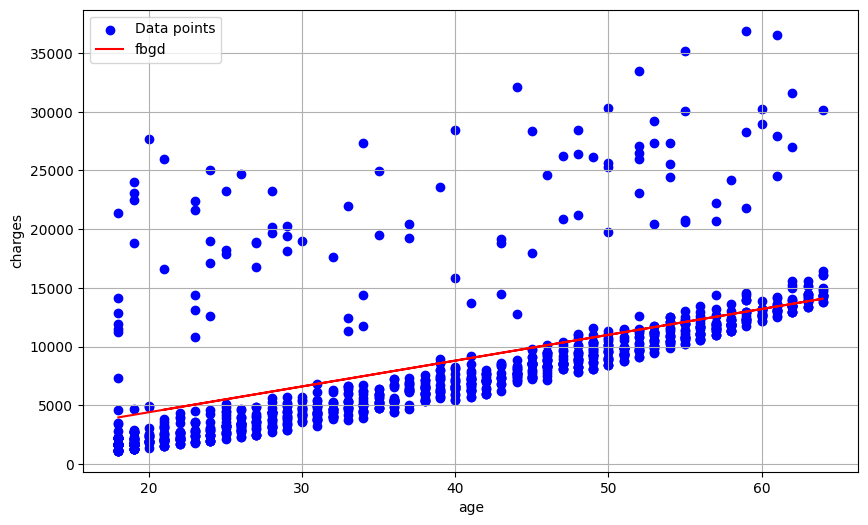

In [238]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, color='blue', label='Data points')
plt.plot(X[:, 0], predictions_fbgd, color='red', label='fbgd')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.grid(True)
plt.show()

## 3. scikit-learn.LinearRegression

In [200]:
X.shape, type(X)

((1064, 1), numpy.ndarray)

In [198]:
y.shape, type(y)

((1064,), numpy.ndarray)

In [193]:
# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()

In [231]:
lin_reg.fit(X, y)

LinearRegression()

In [202]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [201]:
predictions_sklearn = lin_reg.predict(X)

In [214]:
#Порахуємо точність прогнозу за RMSE та оцінимо загалом якість моделі
r2_sklearn = r2_score(y, predictions_sklearn)
rmse_sklearn = root_mean_squared_error(y, predictions_sklearn)
mae_sklearn = mean_absolute_error(y, predictions_sklearn)

print(f"R² score: {r2_sklearn:.2f}")
print(f"Root Mean Squared Error: {rmse_sklearn:.2f}")
print(f"Mean Absolute Error: {mae_sklearn:.2f}")


R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52


## Порівняння результатів

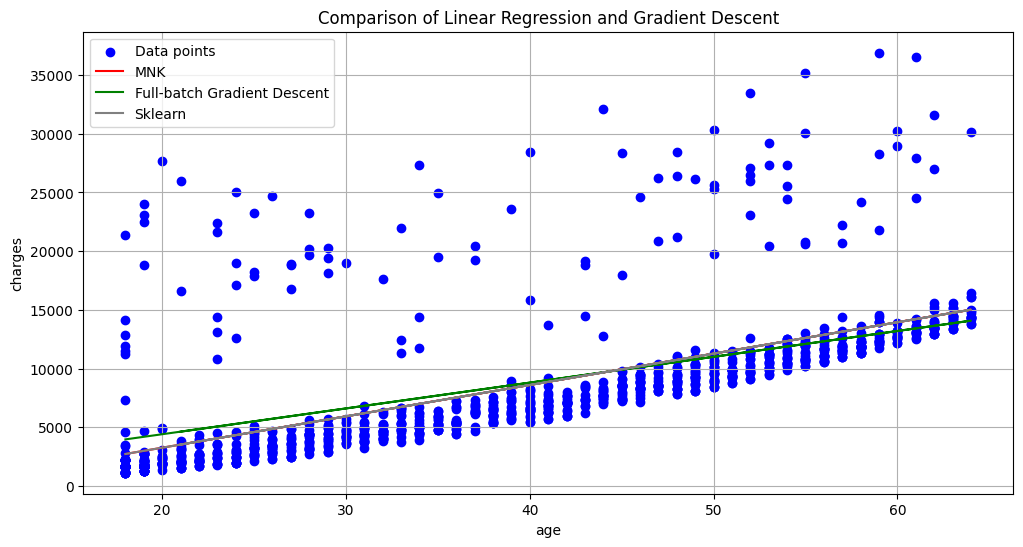

In [239]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], y, color='blue', label='Data points')
plt.plot(X[:, 0], predictions_MNK, color='red', label='MNK')
plt.plot(X[:, 0], predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X[:, 0], predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.grid(True)
plt.show()

На графіку бачимо, що моделі для MNK та sklearn дають однакові прямі

In [215]:
print('MNK')
print(f"R² score: {r2_MNK:.2f}")
print(f"Root Mean Squared Error: {rmse_MNK:.2f}")
print(f"Mean Absolute Error: {mae_MNK:.2f}")

print('\nFBGD')
print(f"R² score: {r2_fbgd4:.2f}")
print(f"Root Mean Squared Error: {rmse_fbgd4:.2f}")
print(f"Mean Absolute Error: {mae_fbgd4:.2f}")

print('\nsklearn')
print(f"R² score: {r2_sklearn:.2f}")
print(f"Root Mean Squared Error: {rmse_sklearn:.2f}")
print(f"Mean Absolute Error: {mae_sklearn:.2f}")


MNK
R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52

FBGD
R² score: 0.38
Root Mean Squared Error: 4715.55
Mean Absolute Error: 2805.42

sklearn
R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52


Висновок:
1. MNK та sklearn очікувано дають однакові результати, оскільки в основі другого варіанту лежить МНК.
2. Кращою з трьох моделей є модель MNK/sklearn, оскільки для цих моделей кращий показник R^2, та менші RMSE.
3. Виходячи із значень R^2, RMSE, MAE, та візуального відображення лінії моделі можна зробити висновок, що модель не повністю визначає `charges` (R^2 < 50%, тобто навіть не половина), і разом з `age`, ймовірно потрібно враховувати додаткові незалежні змінні, які впливають на `charges`

# **Завдання 2.**
Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [217]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [221]:
smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768


In [224]:
X_sm_row = np.array(smoker_df['age'])
X_sm = np.expand_dims(X_sm_row, axis = 1)
#print("Вектор-стовпець незалежних змінних X:\n",X_sm)

y_sm_row = np.array(smoker_df['charges'])
y_sm = np.expand_dims(y_sm_row, axis = 1)
#print("Вектор-стовпець цільової (залежної) змінної у:\n", y_sm)

In [223]:
X_sm.shape, type(X_sm)

((274, 1), numpy.ndarray)

In [226]:
y_sm_row.shape, type(y_sm_row)

((274,), numpy.ndarray)

In [227]:
lin_reg_sm = LinearRegression()

In [229]:
lin_reg_sm.fit(X_sm, y_sm_row)

LinearRegression()

In [230]:
lin_reg_sm.coef_, lin_reg_sm.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [232]:
predictions_sklearn_sm = lin_reg_sm.predict(X_sm)

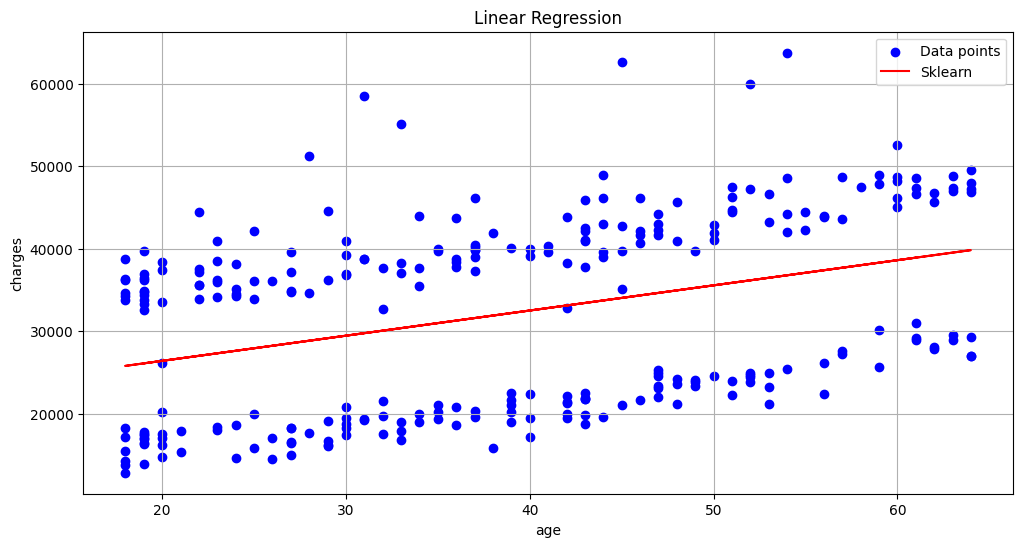

In [236]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(X_sm[:, 0], y_sm_row, color='blue', label='Data points')
plt.plot(X_sm[:, 0], predictions_sklearn_sm, color='red', label='Sklearn')
plt.title('Linear Regression')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend()
plt.grid(True)
plt.show()

In [234]:
#Порахуємо точність прогнозу за RMSE та оцінимо загалом якість моделі
r2_sklearn_sm = r2_score(y_sm_row, predictions_sklearn_sm)
rmse_sklearn_sm = root_mean_squared_error(y_sm_row, predictions_sklearn_sm)
mae_sklearn_sm = mean_absolute_error(y_sm_row, predictions_sklearn_sm)

print(f"R² score: {r2_sklearn_sm:.2f}")
print(f"Root Mean Squared Error: {rmse_sklearn_sm:.2f}")
print(f"Mean Absolute Error: {mae_sklearn_sm:.2f}")

R² score: 0.14
Root Mean Squared Error: 10711.00
Mean Absolute Error: 10097.80


In [235]:
np.mean(y_sm_row), np.std(y_sm_row)

(np.float64(32050.23183153284), np.float64(11520.46670652943))

На основі отриманих значень R^2, RMSE, MAE та візуального відображення можна зробити висновок про низьку якість моделі. Візуально видно, що лінія моделі лежить між двома кластерами (між двома лініями реальних точок). Також R^2 має мале значення.

Ймовірно, модель не включає важливі змінні, які впливають на значення цільової змінної.